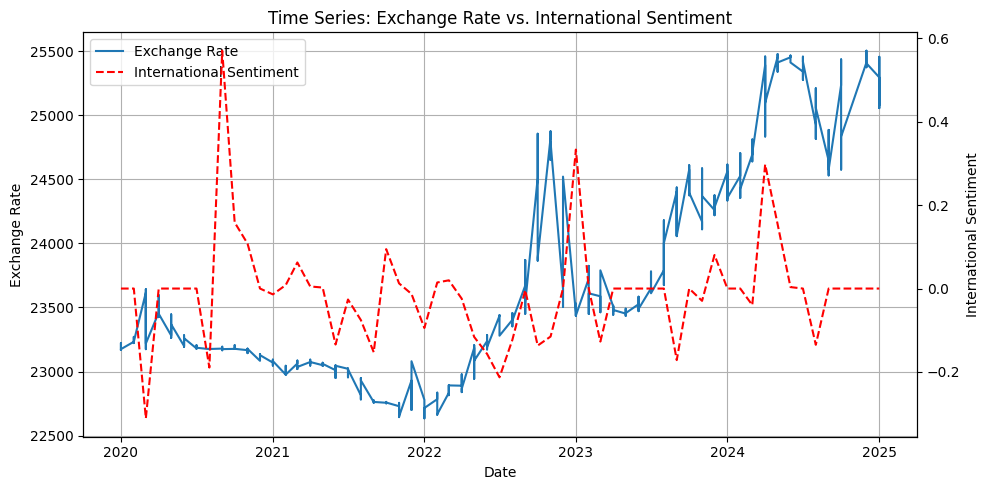


Regression: exr on int_sen
                            OLS Regression Results                            
Dep. Variable:                    exr   R-squared:                       0.004
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     5.981
Date:                Sun, 24 May 2026   Prob (F-statistic):             0.0146
Time:                        20:52:43   Log-Likelihood:                -10224.
No. Observations:                1256   AIC:                         2.045e+04
Df Residuals:                    1254   BIC:                         2.046e+04
Df Model:                           1                                         
Covariance Type:                  HC1                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        2.37e+04   

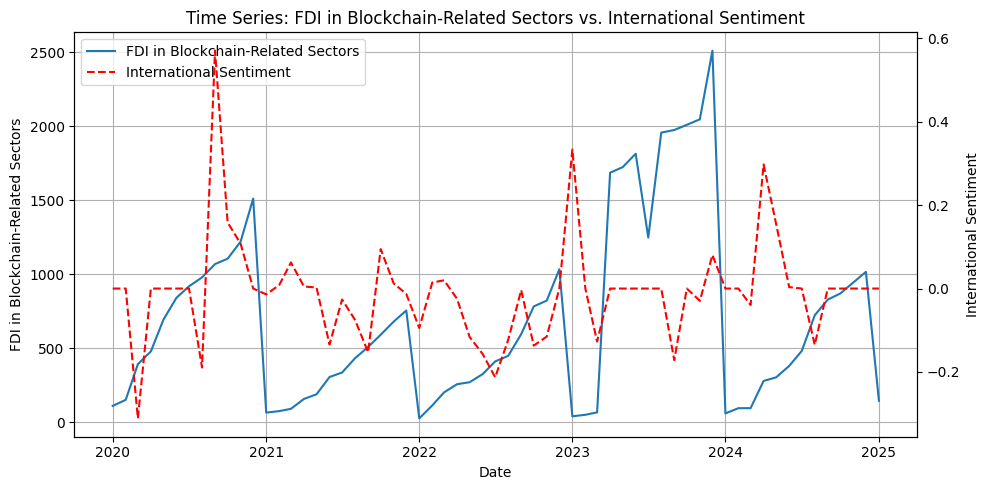


Regression: fdi_bs on int_sen
                            OLS Regression Results                            
Dep. Variable:                 fdi_bs   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                  0.002
Method:                 Least Squares   F-statistic:                     6.426
Date:                Sun, 24 May 2026   Prob (F-statistic):             0.0114
Time:                        20:52:43   Log-Likelihood:                -9848.8
No. Observations:                1256   AIC:                         1.970e+04
Df Residuals:                    1254   BIC:                         1.971e+04
Df Model:                           1                                         
Covariance Type:                  HC1                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        691.0898

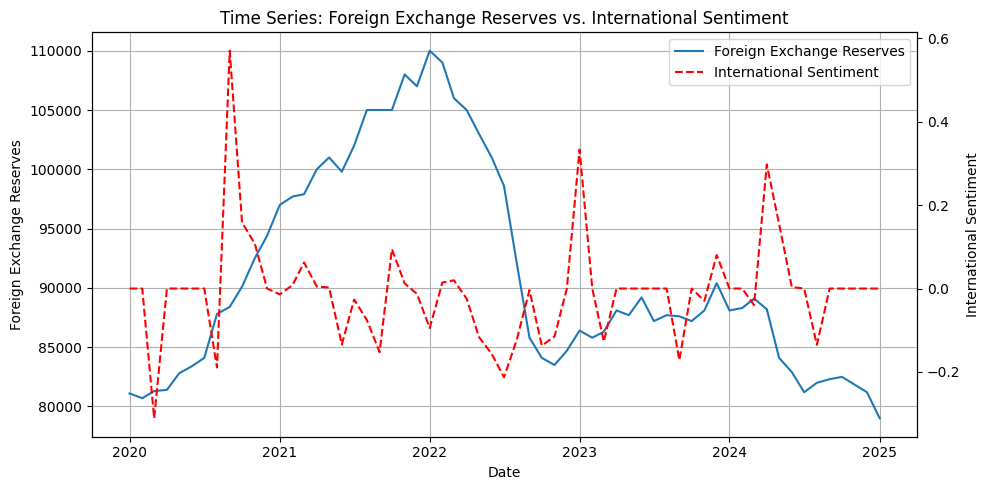


Regression: fxr on int_sen
                            OLS Regression Results                            
Dep. Variable:                    fxr   R-squared:                       0.007
Model:                            OLS   Adj. R-squared:                  0.007
Method:                 Least Squares   F-statistic:                     19.83
Date:                Sun, 24 May 2026   Prob (F-statistic):           9.24e-06
Time:                        20:52:44   Log-Likelihood:                -13186.
No. Observations:                1256   AIC:                         2.638e+04
Df Residuals:                    1254   BIC:                         2.639e+04
Df Model:                           1                                         
Covariance Type:                  HC1                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       9.119e+04   

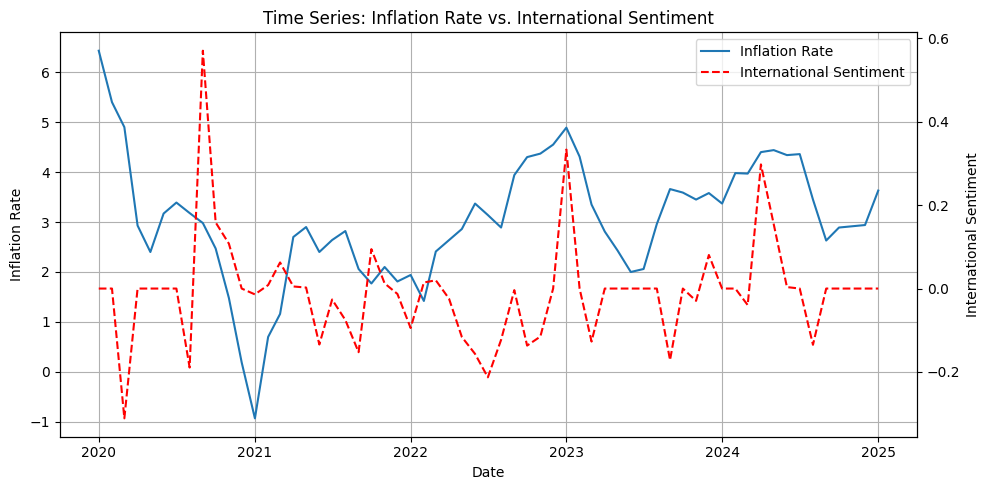


Regression: inf on int_sen
                            OLS Regression Results                            
Dep. Variable:                    inf   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.001
Method:                 Least Squares   F-statistic:                    0.4546
Date:                Sun, 24 May 2026   Prob (F-statistic):              0.500
Time:                        20:52:44   Log-Likelihood:                -2039.2
No. Observations:                1256   AIC:                             4082.
Df Residuals:                    1254   BIC:                             4093.
Df Model:                           1                                         
Covariance Type:                  HC1                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          3.0421   

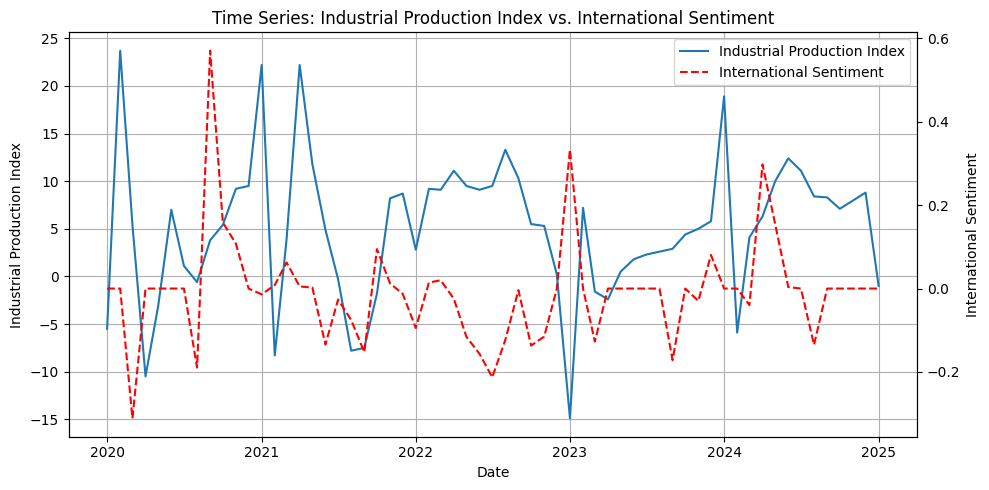


Regression: ipi on int_sen
                            OLS Regression Results                            
Dep. Variable:                    ipi   R-squared:                       0.006
Model:                            OLS   Adj. R-squared:                  0.005
Method:                 Least Squares   F-statistic:                     8.298
Date:                Sun, 24 May 2026   Prob (F-statistic):            0.00404
Time:                        20:52:44   Log-Likelihood:                -4298.0
No. Observations:                1256   AIC:                             8600.
Df Residuals:                    1254   BIC:                             8610.
Df Model:                           1                                         
Covariance Type:                  HC1                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          4.9237   

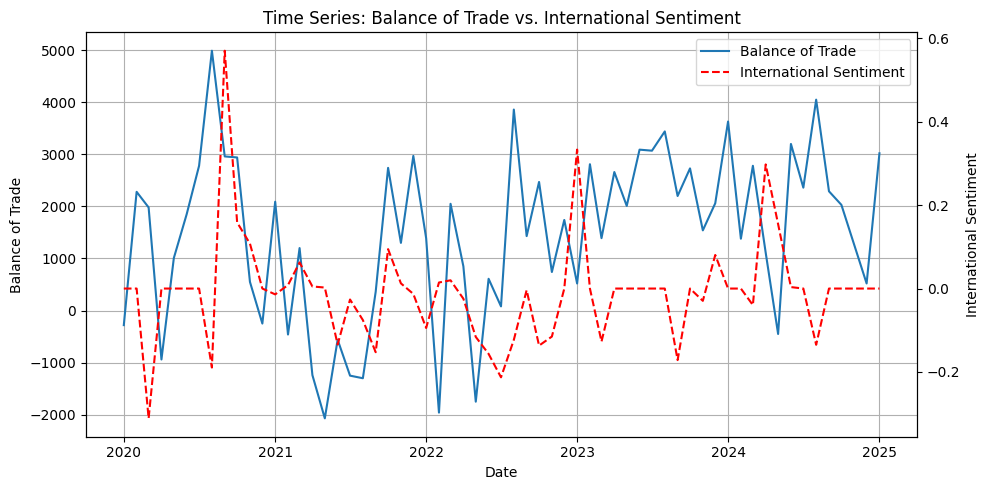


Regression: bot on int_sen
                            OLS Regression Results                            
Dep. Variable:                    bot   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                    0.6704
Date:                Sun, 24 May 2026   Prob (F-statistic):              0.413
Time:                        20:52:44   Log-Likelihood:                -11051.
No. Observations:                1256   AIC:                         2.211e+04
Df Residuals:                    1254   BIC:                         2.212e+04
Df Model:                           1                                         
Covariance Type:                  HC1                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       1475.3661   

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since fu

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, grangercausalitytests

# Load data
df = pd.read_csv("merged_variables.csv")

# Convert monthly date if needed
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date").set_index("Date")

# Variables
target_vars = {
    "exr": "Exchange Rate",
    "fdi_bs": "FDI in Blockchain-Related Sectors",
    "fxr": "Foreign Exchange Reserves",
    "inf": "Inflation Rate",
    "ipi": "Industrial Production Index",
    "bot": "Balance of Trade"
}

# Plot function
def plot_dual_axis(y_var, y_label, filename):
    fig, ax1 = plt.subplots(figsize=(10, 5))

    ax1.plot(df.index, df[y_var], label=y_label)
    ax1.set_xlabel("Date")
    ax1.set_ylabel(y_label)
    ax1.grid(True)

    ax2 = ax1.twinx()
    ax2.plot(df.index, df["int_sen"], color="red", linestyle="--", label="International Sentiment")
    ax2.set_ylabel("International Sentiment")

    plt.title(f"Time Series: {y_label} vs. International Sentiment")

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2)

    plt.tight_layout()
    plt.savefig(filename, dpi=300)
    plt.show()

# Robust regression function
def robust_regression(y_var):
    data = df[[y_var, "int_sen"]].dropna()
    X = sm.add_constant(data["int_sen"])
    y = data[y_var]

    model = sm.OLS(y, X).fit(cov_type="HC1")
    print(f"\nRegression: {y_var} on int_sen")
    print(model.summary())
    return model

# Graphs and regressions
models = {}

for var, label in target_vars.items():
    plot_dual_axis(
        y_var=var,
        y_label=label,
        filename=f"{var}_int_sen_combined.png"
    )
    models[var] = robust_regression(var)

# Save regression results into one text file
with open("model2a_results.txt", "w") as f:
    for var, model in models.items():
        f.write(f"\n\n==============================\n")
        f.write(f"Regression: {var} on int_sen\n")
        f.write("==============================\n")
        f.write(model.summary().as_text())

# Granger causality tests
lag_settings = {
    "exr": 2,
    "fdi_bs": 5,
    "fxr": 2,
    "inf": 4,
    "ipi": 2,
    "bot": 6,
}

for var, max_lag in lag_settings.items():
    print("\n" + "=" * 60)
    print(f"GRANGER CAUSALITY TEST: int_sen -> {var}")
    print("=" * 60)

    test_data = df[[var, "int_sen"]].dropna()

    # Unit root tests
    print(f"\nADF Test for {var}:")
    adf_result = adfuller(test_data[var])
    print(f"ADF Statistic: {adf_result[0]:.4f}")
    print(f"p-value: {adf_result[1]:.4f}")

    print("\nGranger Causality Results:")
    grangercausalitytests(test_data[[var, "int_sen"]], maxlag=max_lag, verbose=True)
